In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
print("Data type of TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nBlank/whitespace values in TotalCharges:")
print((df["TotalCharges"].astype(str).str.strip() == "").sum())

print("\nFirst 10 values:")
print(df["TotalCharges"].head(10))

Data type of TotalCharges:
object

Blank/whitespace values in TotalCharges:
11

First 10 values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Data type after conversion:")
print(df["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df["TotalCharges"].isnull().sum())

print("\nRows with missing TotalCharges:")
print(df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

Data type after conversion:
float64

Missing values after conversion:
11

Rows with missing TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [14]:
# Handle missing values in TotalCharges

print("Missing values before cleaning:")
print(df["TotalCharges"].isnull().sum())

# Replace missing TotalCharges values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("\nMissing values after cleaning:")
print(df["TotalCharges"].isnull().sum())

print("\nFinal data type:")
print(df["TotalCharges"].dtype)

Missing values before cleaning:
11

Missing values after cleaning:
0

Final data type:
float64


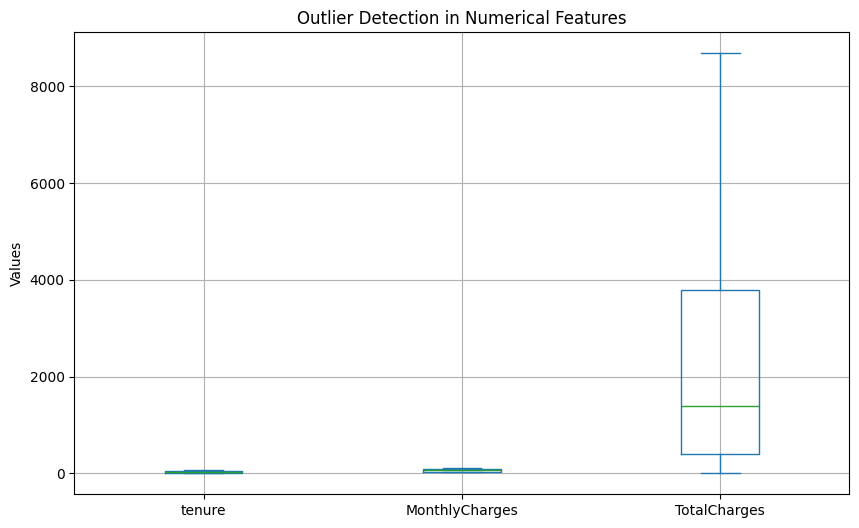

In [15]:
import matplotlib.pyplot as plt
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numerical_columns].plot(kind="box", figsize=(10, 6))
plt.title("Outlier Detection in Numerical Features")
plt.ylabel("Values")
plt.grid(True)
plt.show()

In [17]:
# Data Preprocessing: Encode categorical variables

# Remove customerID because it is only an identifier
df_processed = df.drop("customerID", axis=1)

# Convert categorical columns into numerical values
df_processed = pd.get_dummies(df_processed, drop_first=True)

print("Original dataset shape:", df.shape)
print("Processed dataset shape:", df_processed.shape)

print("\nFirst 5 rows of the processed dataset:")
print(df_processed.head())

Original dataset shape: (7043, 21)
Processed dataset shape: (7043, 31)

First 5 rows of the processed dataset:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            Fa

In [19]:
# Final Cleaned Dataset Summary

print("Final dataset shape:", df_processed.shape)

print("\nTotal missing values:", df_processed.isnull().sum().sum())

print("\nData types:")
print(df_processed.dtypes.value_counts())

# Save the final cleaned dataset
df_processed.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

print("\nStatus: Cleaned dataset successfully saved!")

Final dataset shape: (7043, 31)

Total missing values: 0

Data types:
bool       27
int64       2
float64     2
Name: count, dtype: int64

Status: Cleaned dataset successfully saved!


In [20]:
from google.colab import files

files.download("Telco_Customer_Churn_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>